In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

df = pd.read_csv('../data/processed/pharma_sales_cleaned.csv')

In [2]:
#Revenue KPI
df['revenue'] = df['units_sold'] * df['unit_price']

In [3]:
#Region-Level KPIs
region_kpis = (
    df.groupby('region')
    .agg({
        'revenue': 'sum',
        'units_sold': 'sum',
        'stock_level': 'mean'
    })
    .reset_index()
)

region_kpis

,region,revenue,units_sold,stock_level
0,Africa,5.128403e+08,9733935,4556.151369
1,East Asia,5.192713e+08,9837720,4551.934945
2,Europe,5.163563e+08,9782351,4554.947308
3,Middle East,5.156810e+08,9849229,4551.884717
4,North America,5.151863e+08,9799919,4553.607162
5,Oceania,5.155757e+08,9847959,4552.617290
6,South America,5.188874e+08,9838549,4551.784945
7,South Asia,5.138564e+08,9844922,4552.133212


In [4]:
#Yearly Regional Revenue
regional_growth = (
    df.groupby(['year', 'region'])['revenue']
    .sum()
    .reset_index()
)

regional_growth.head()

,year,region,revenue
0,2020,Africa,1.135774e+08
1,2020,East Asia,1.164693e+08
2,2020,Europe,1.148396e+08
3,2020,Middle East,1.175345e+08
4,2020,North America,1.155874e+08


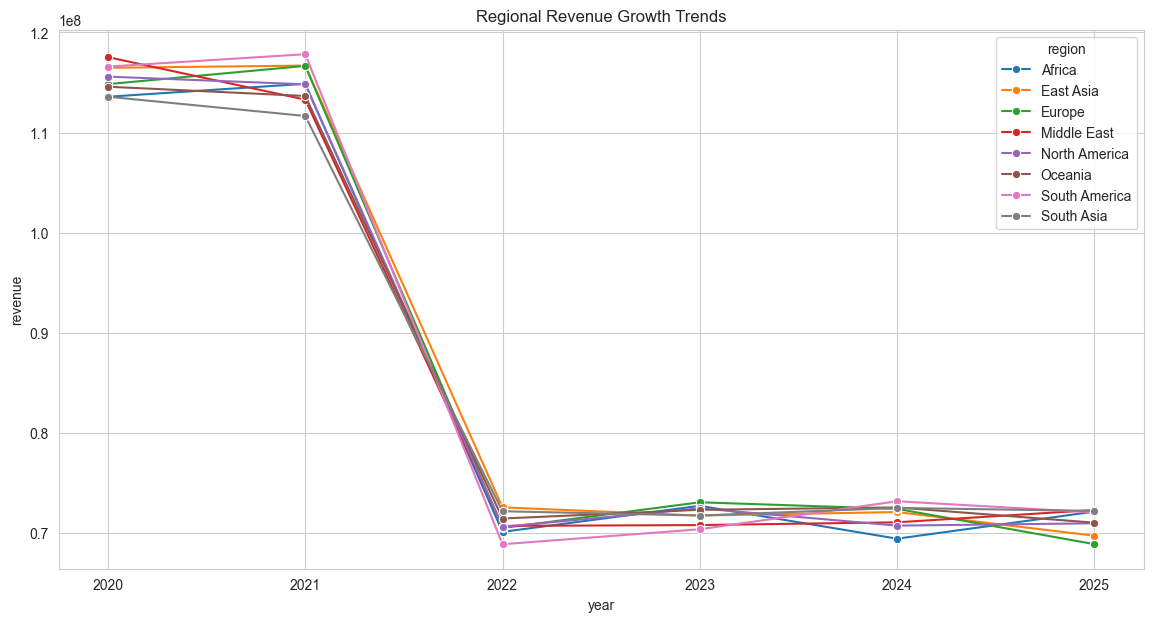

In [5]:
plt.figure(figsize=(14,7))

sns.lineplot(
    data=regional_growth,
    x='year',
    y='revenue',
    hue='region',
    marker='o'
)

plt.title('Regional Revenue Growth Trends')

plt.show()

In [6]:
#Growth Rate
growth_analysis = (
    regional_growth.pivot(
        index='year',
        columns='region',
        values='revenue'
    )
)

growth_analysis

region,Africa,East Asia,Europe,Middle East,North America,Oceania,South America,South Asia
year,,,,,,,,
2020,1.135774e+08,1.164693e+08,1.148396e+08,1.175345e+08,1.155874e+08,1.145808e+08,1.165907e+08,1.135764e+08
2021,1.148723e+08,1.166887e+08,1.166590e+08,1.132858e+08,1.148196e+08,1.136533e+08,1.178252e+08,1.116558e+08
2022,7.011164e+07,7.255693e+07,7.049413e+07,7.071059e+07,7.061471e+07,7.144505e+07,6.887716e+07,7.217076e+07
2023,7.271377e+07,7.173742e+07,7.306659e+07,7.078905e+07,7.246195e+07,7.231570e+07,7.037128e+07,7.174457e+07
2024,6.943143e+07,7.209205e+07,7.241070e+07,7.106626e+07,7.073564e+07,7.255185e+07,7.316931e+07,7.250211e+07
2025,7.213375e+07,6.972692e+07,6.888623e+07,7.229483e+07,7.096698e+07,7.102894e+07,7.205374e+07,7.220669e+07


In [7]:
#Year-over-Year Growth
growth_rate = growth_analysis.pct_change() * 100

growth_rate

region,Africa,East Asia,Europe,Middle East,North America,Oceania,South America,South Asia
year,,,,,,,,
2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021,1.140161,0.188365,1.584307,-3.614879,-0.664263,-0.809467,1.058834,-1.690964
2022,-38.965608,-37.820068,-39.572502,-37.582123,-38.499435,-37.137730,-41.542940,-35.363199
2023,3.711416,-1.129472,3.649181,0.110965,2.615953,1.218633,2.169248,-0.590537
2024,-4.514051,0.494336,-0.897665,0.391600,-2.382375,0.326552,3.976108,1.055885
2025,3.892067,-3.280697,-4.867334,1.728766,0.327050,-2.099064,-1.524648,-0.407470


In [8]:
#Category KPIs
category_kpis = (
    df.groupby('category')
    .agg({
        'revenue': 'sum',
        'units_sold': 'sum',
        'stock_level': 'mean'
    })
    .reset_index()
)

category_kpis

,category,revenue,units_sold,stock_level
0,Antibiotic,8.265009e+08,15679787,4554.247605
1,Antipyretic,8.295979e+08,15759748,4551.053718
2,Chronic,8.213407e+08,15687400,4553.408360
3,Cough_Cold,8.276622e+08,15679474,4554.217296
4,Vitamin,8.225529e+08,15728175,4552.736114


In [9]:
#Demand Volatility Analysis
volatility = (
    df.groupby('category')['units_sold']
    .std()
    .sort_values(ascending=False)
)

volatility

category
Vitamin        345.302626
Antipyretic    344.096363
Chronic        338.283020
Cough_Cold     337.068616
Antibiotic     329.461767
Name: units_sold, dtype: float64

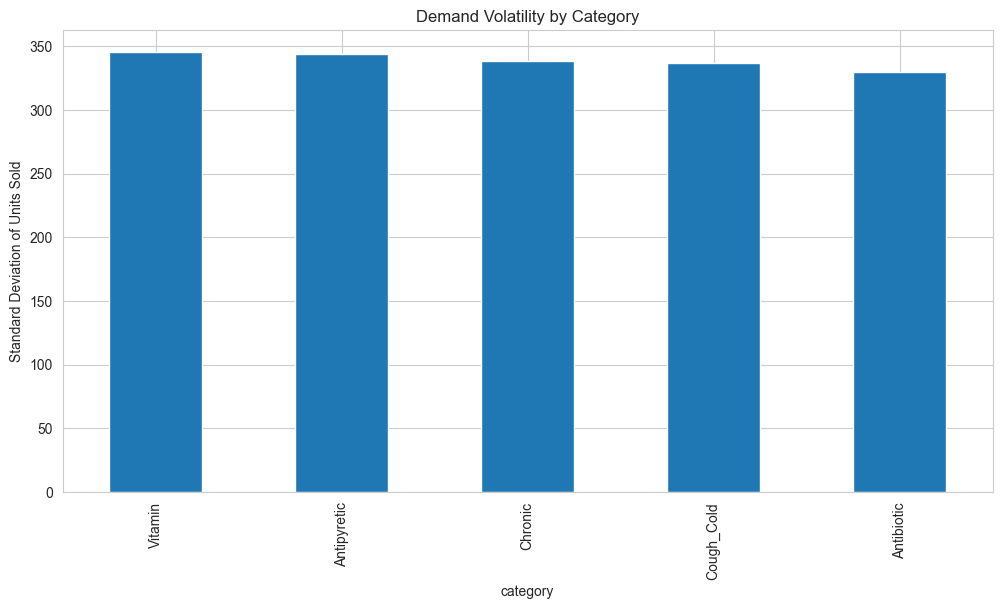

In [10]:
volatility.plot(
    kind='bar'
)

plt.title('Demand Volatility by Category')
plt.ylabel('Standard Deviation of Units Sold')

plt.show()

In [11]:
#Age Group Business Analysis
age_group_analysis = (
    df.groupby('age_group')['revenue']
    .sum()
    .sort_values(ascending=False)
)

age_group_analysis

age_group
46-65    8.390968e+08
65+      8.274585e+08
0-12     8.219388e+08
26-45    8.207466e+08
13-25    8.184140e+08
Name: revenue, dtype: float64